In [2]:
import os
from dotenv import load_dotenv
import oracledb
import pandas as pd

load_dotenv()

USER = os.getenv("USER")
PASSWORD = os.getenv("PASSWORD")
DSN = os.getenv("DSN")

with oracledb.connect(user=USER, password=PASSWORD, dsn=DSN) as conn:
    df = pd.read_sql("SELECT * FROM DELIVERY_ORDERS", conn)

df.head()


C:\Users\lkw\AppData\Local\Temp\ipykernel_680\3775214346.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM DELIVERY_ORDERS", conn)


,ORDER_ID,MENU_NAME,CATEGORY,PRICE,RATING,REGION,ORDER_DATE
0,1,떡볶이,분식,9000,4.5,강남구,2026-08-01
1,2,치킨,치킨,22000,4.8,서초구,2026-08-02
2,3,피자,피자,25000,4.2,강남구,2026-08-03
3,4,짜장면,중식,8000,4.0,송파구,2026-08-04
4,5,마라탕,중식,13000,4.6,강남구,2026-08-05


In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rc('font', family='Malgun Gothic')
mpl.rc('axes', unicode_minus=False)

CATEGORY
피자    25666.666667
치킨    22250.000000
일식    14687.500000
중식    11800.000000
분식     7642.857143
Name: PRICE, dtype: float64


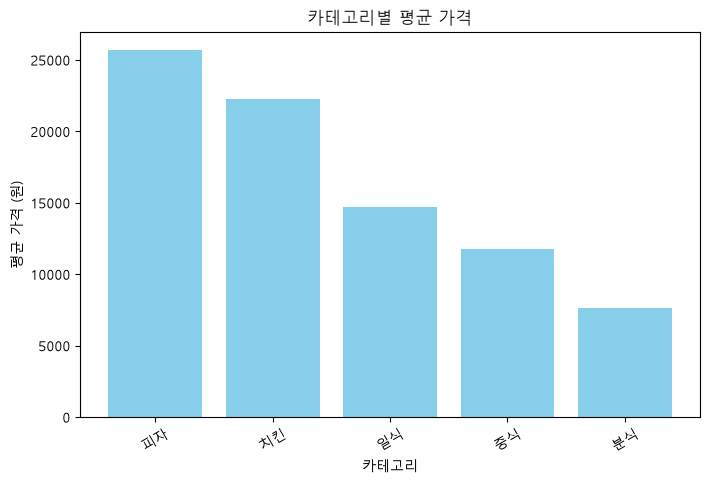

In [ ]:
# 범주형 데이터에서는 바 차트가 적합
category_price = df.groupby("CATEGORY")["PRICE"].mean().sort_values(ascending=False)
print(category_price)

plt.figure(figsize=(8,5))
plt.bar(category_price.index, category_price.values, color="skyblue")
plt.title("카테고리별 평균 가격")
plt.xlabel("카테고리")
plt.ylabel("평균 가격 (원)")
plt.xticks(rotation=30)
plt.show()

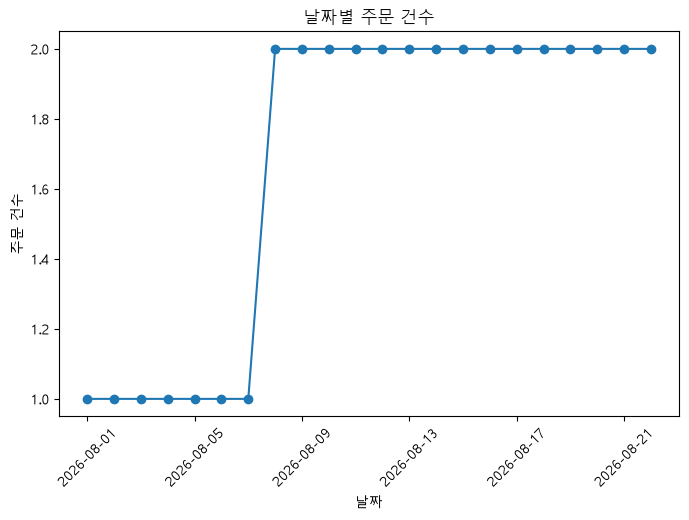

In [ ]:
# 시간/날짜 같은 시계열에서는 line차트가 적합
daily_count = df.groupby("ORDER_DATE").size()     # size(): NaN값을 포함해서 개수를 셈 -> 행/줄 개수  | count(): NaN값 제외

plt.figure(figsize=(8,5))
plt.plot(daily_count.index, daily_count.values, marker="o")
plt.title("날짜별 주문 건수")
plt.xlabel("날짜")
plt.ylabel("주문 건수")
plt.xticks(rotation=45)
plt.show()

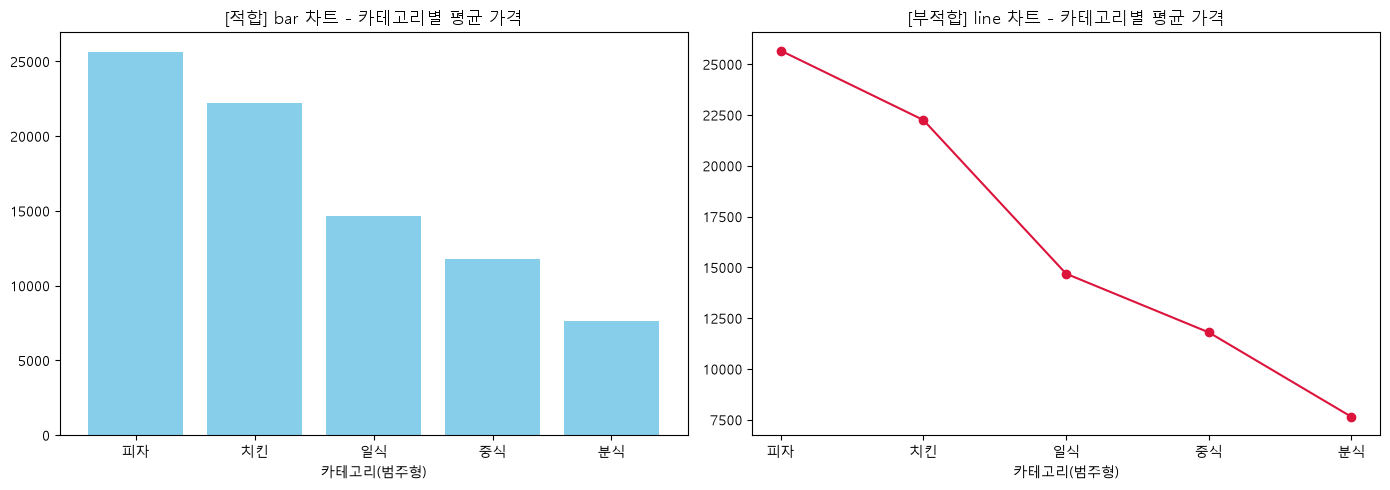

In [17]:
# 같은 데이터를 bar와 line 둘다 그려서 비교
category_price = df.groupby("CATEGORY")["PRICE"].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1,2, figsize = (14,5))
axes[0].bar(category_price.index, category_price.values, color="skyblue")
axes[0].set_title("[적합] bar 차트 - 카테고리별 평균 가격")
axes[0].set_xlabel("카테고리(범주형)")

axes[1].plot(category_price.index, category_price.values, marker="o", color = "crimson")
axes[1].set_title("[부적합] line 차트 - 카테고리별 평균 가격")
axes[1].set_xlabel("카테고리(범주형)")

plt.tight_layout()   # 겹치지 않게 자동 여백
plt.show()

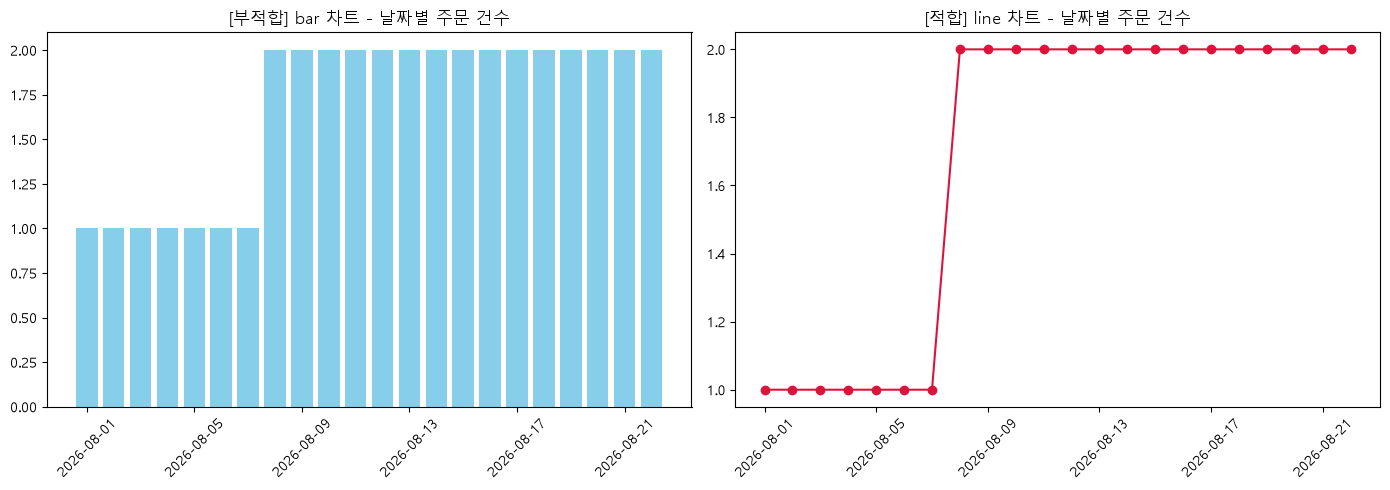

In [19]:
# 시계열 데이터를 bar와 line 둘다 그려서 비교
daily_count = df.groupby("ORDER_DATE").size() 

fig, axes = plt.subplots(1,2, figsize = (14,5))
axes[0].bar(daily_count.index, daily_count.values, color="skyblue")
axes[0].set_title("[부적합] bar 차트 - 날짜별 주문 건수")
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(daily_count.index, daily_count.values, marker="o", color = "crimson")
axes[1].set_title("[적합] line 차트 - 날짜별 주문 건수")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()   # 겹치지 않게 자동 여백
plt.show()

In [20]:
category_price_unsorted = df.groupby("CATEGORY")["PRICE"].mean()  # 정렬 안 함
category_price_sorted = df.groupby("CATEGORY")["PRICE"].mean().sort_values(ascending=False)  # 내림차순 정렬

print("=== 정렬 전 (groupby 기본 순서) ===")
print(category_price_unsorted)
print("\n=== 정렬 후 (sort_values ascending=False) ===")
print(category_price_sorted)

=== 정렬 전 (groupby 기본 순서) ===
CATEGORY
분식     7642.857143
일식    14687.500000
중식    11800.000000
치킨    22250.000000
피자    25666.666667
Name: PRICE, dtype: float64

=== 정렬 후 (sort_values ascending=False) ===
CATEGORY
피자    25666.666667
치킨    22250.000000
일식    14687.500000
중식    11800.000000
분식     7642.857143
Name: PRICE, dtype: float64


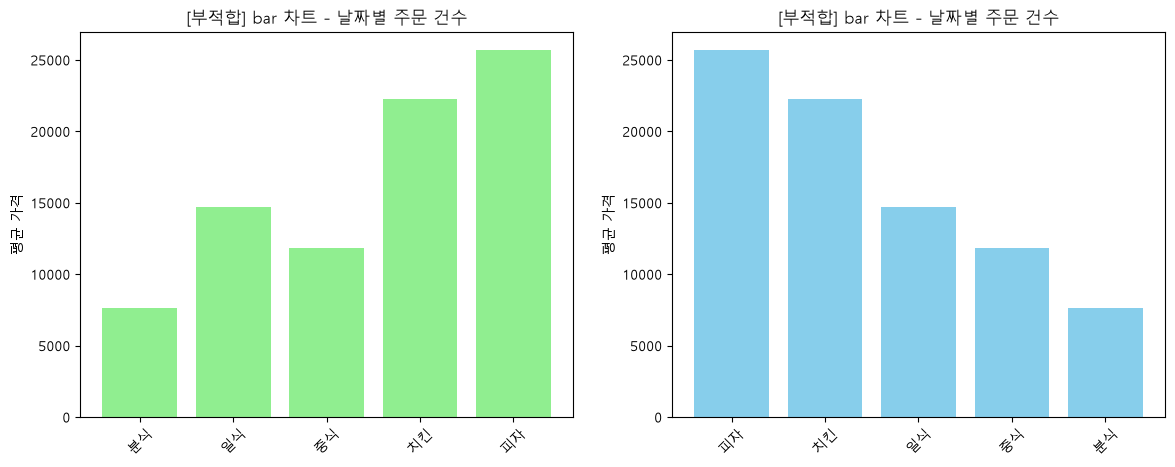

In [ ]:
fig, axes = plt.subplots(1,2, figsize = (14, 5))

# 왼쪽: 정렬 안 한 상태 - 카테고리명 순서
axes[0].bar(category_price_unsorted.index, category_price_unsorted.values, color="lightgreen")
axes[0].set_title("정렬 안함 (카테고리명 순서)")
axes[0].set_ylabel("평균 가격")
axes[0].tick_params(axis='x', rotation=45)

# 오른쪽: 내림차순 정렬 - 가격 높은 순
axes[1].bar(category_price_sorted.index, category_price_sorted.values, color="skyblue")
axes[1].set_title("sort_values(ascending = False)적용")
axes[1].set_ylabel("평균 가격")
axes[1].tick_params(axis='x', rotation=45)